# Data Distribution

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats as st

### Load Dataset

In [2]:
df = sns.load_dataset('tips')
df.head()
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


## Draw Hisplot

<Axes: xlabel='total_bill', ylabel='Count'>

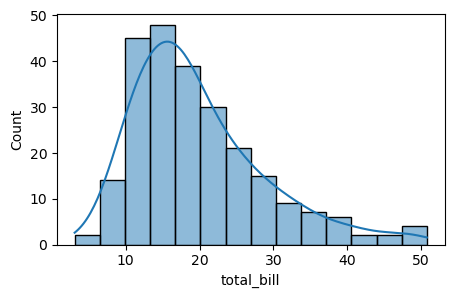

In [9]:
plt.figure(figsize=(5, 3))
sns.histplot(data=df, x='total_bill', kde=True)

<Axes: xlabel='age', ylabel='Count'>

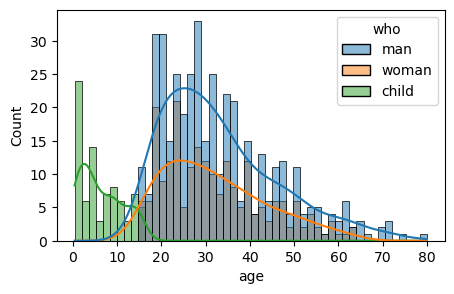

In [11]:
df_01 = sns.load_dataset('titanic')
plt.figure(figsize=(5, 3))
sns.histplot(data=df_01, x='age', kde=True, bins=50, hue="who")

<Axes: xlabel='age'>

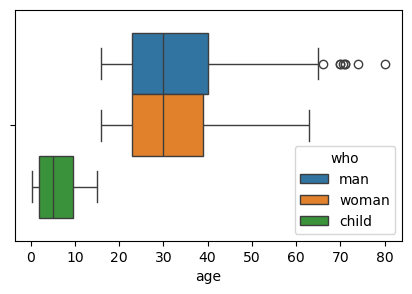

In [14]:
plt.figure(figsize=(5, 3))
sns.boxplot(data=df_01, x='age', hue="who")

<Axes: xlabel='age'>

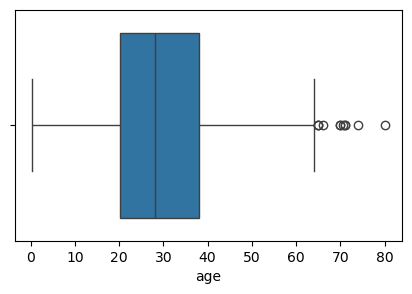

In [15]:
plt.figure(figsize=(5, 3))
sns.boxplot(data=df_01, x='age')

<Axes: xlabel='age'>

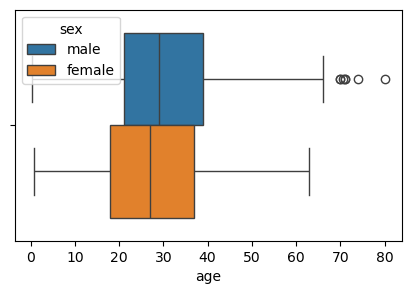

In [16]:
plt.figure(figsize=(5, 3))
sns.boxplot(data=df_01, x='age', hue="sex")

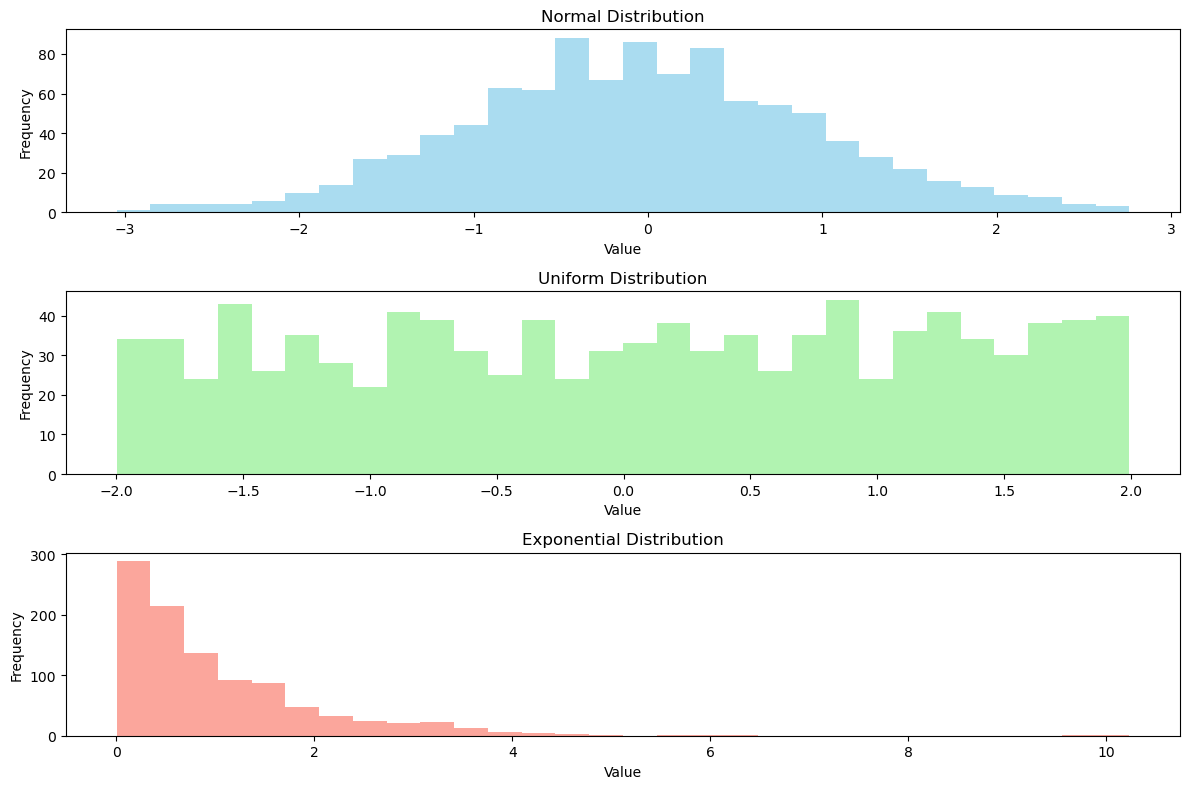

In [17]:
# Generating example datasets with different distributions
np.random.seed(0)  # For reproducibility

# Normal distribution data
normal_data = np.random.normal(loc=0, scale=1, size=1000)

# Uniform distribution data
uniform_data = np.random.uniform(low=-2, high=2, size=1000)

# Exponential distribution data
exponential_data = np.random.exponential(scale=1, size=1000)

# Plotting the distributions
plt.figure(figsize=(12, 8))

# Normal Distribution Plot
plt.subplot(3, 1, 1)
plt.hist(normal_data, bins=30, color='skyblue', alpha=0.7)
plt.title('Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Uniform Distribution Plot
plt.subplot(3, 1, 2)
plt.hist(uniform_data, bins=30, color='lightgreen', alpha=0.7)
plt.title('Uniform Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

# Exponential Distribution Plot
plt.subplot(3, 1, 3)
plt.hist(exponential_data, bins=30, color='salmon', alpha=0.7)
plt.title('Exponential Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [3]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


<Axes: >

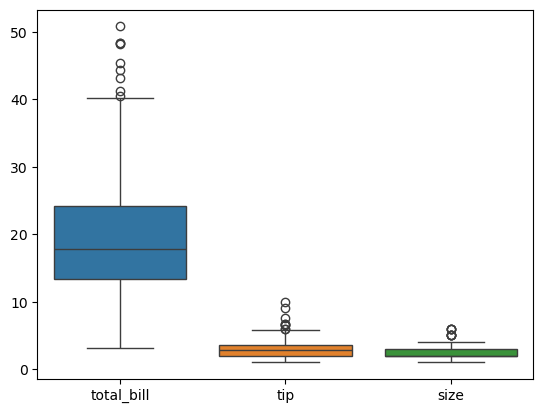

In [6]:
sns.boxplot(data=df)

<Axes: >

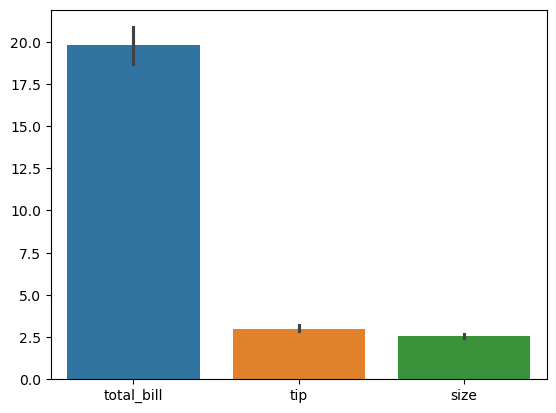

In [10]:
sns.barplot(data=df)

<Axes: xlabel='total_bill'>

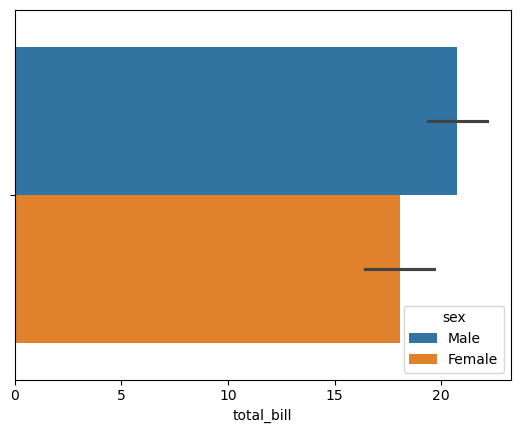

In [12]:
sns.barplot(x=df['total_bill'], hue=df['sex'])

<Axes: ylabel='total_bill'>

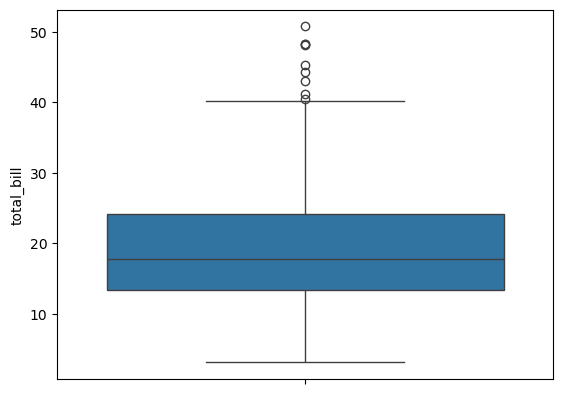

In [14]:
sns.boxplot(data=df['total_bill'])

<Axes: ylabel='tip'>

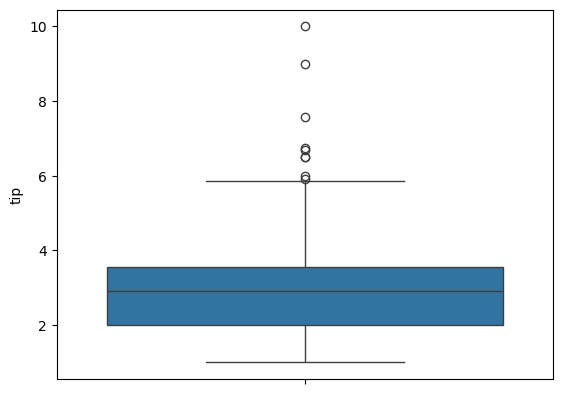

In [15]:
sns.boxplot(data=df['tip'])

<Axes: ylabel='size'>

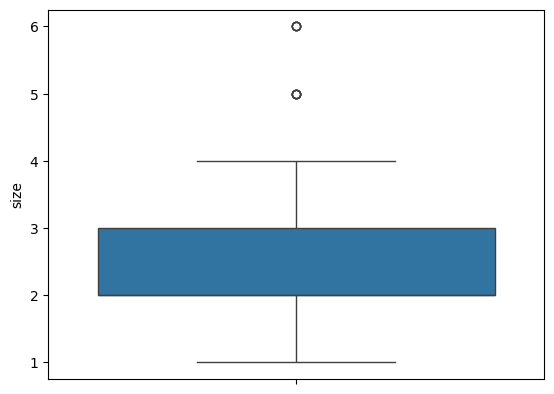

In [16]:
sns.boxplot(data=df['size'])

In [18]:
size_col = df['size']
tip_col = df['tip']
total_bill_col = df['total_bill']

In [38]:
def handle_outliers_iqr(df, column_name):
    col = df[column_name]
    
    print(f"\n========== {column_name.upper()} ==========\n")
    
    # -----------------------------
    # 1. 5 Number Summary
    # -----------------------------
    minimum = col.min()
    q1 = col.quantile(0.25)
    median = col.median()
    q3 = col.quantile(0.75)
    maximum = col.max()

    print(f"{column_name} Minimum: {minimum}")
    print(f"{column_name} Q1: {q1}")
    print(f"{column_name} Median: {median}")
    print(f"{column_name} Q3: {q3}")
    print(f"{column_name} Maximum: {maximum}\n")

    # -----------------------------
    # 2. IQR
    # -----------------------------
    iqr = q3 - q1
    print(f"{column_name} IQR: {iqr}\n")

    # -----------------------------
    # 3. Bounds
    # -----------------------------
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    print(f"{column_name} Lower Bound: {lower_bound}")
    print(f"{column_name} Upper Bound: {upper_bound}\n")

    # -----------------------------
    # 4. Detect Outliers
    # -----------------------------
    outliers = col[(col < lower_bound) | (col > upper_bound)]
    print(f"{column_name} Outliers Count: {len(outliers)}")

    # -----------------------------
    # 5. Capping (Best Practice)
    # -----------------------------
    df[column_name] = col.clip(lower=lower_bound, upper=upper_bound)

    print(f"{column_name} Outliers handled successfully!\n")

    # -----------------------------
    # 6. Verify
    # -----------------------------
    new_outliers = df[column_name][
        (df[column_name] < lower_bound) | (df[column_name] > upper_bound)
    ]
    print(f"{column_name} Outliers after cleaning: {len(new_outliers)}")

    return df

In [43]:
df = handle_outliers_iqr(df, 'total_bill')


========== TOTAL_BILL ==========

total_bill Minimum: 3.07
total_bill Q1: 13.3475
total_bill Median: 17.795
total_bill Q3: 24.127499999999998
total_bill Maximum: 50.81

total_bill IQR: 10.779999999999998

total_bill Lower Bound: -2.8224999999999945
total_bill Upper Bound: 40.29749999999999

total_bill Outliers Count: 9
total_bill Outliers handled successfully!

total_bill Outliers after cleaning: 0


In [44]:
df = handle_outliers_iqr(df, 'size')


========== SIZE ==========

size Minimum: 1.0
size Q1: 2.0
size Median: 2.0
size Q3: 3.0
size Maximum: 4.5

size IQR: 1.0

size Lower Bound: 0.5
size Upper Bound: 4.5

size Outliers Count: 0
size Outliers handled successfully!

size Outliers after cleaning: 0


In [45]:
df = handle_outliers_iqr(df, 'tip')


========== TIP ==========

tip Minimum: 1.0
tip Q1: 2.0
tip Median: 2.9
tip Q3: 3.5625
tip Maximum: 10.0

tip IQR: 1.5625

tip Lower Bound: -0.34375
tip Upper Bound: 5.90625

tip Outliers Count: 9
tip Outliers handled successfully!

tip Outliers after cleaning: 0


In [46]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01000,Female,No,Sun,Dinner,2.0
1,10.34,1.66000,Male,No,Sun,Dinner,3.0
2,21.01,3.50000,Male,No,Sun,Dinner,3.0
3,23.68,3.31000,Male,No,Sun,Dinner,2.0
4,24.59,3.61000,Female,No,Sun,Dinner,4.0
...,...,...,...,...,...,...,...
239,29.03,5.90625,Male,No,Sat,Dinner,3.0
240,27.18,2.00000,Female,Yes,Sat,Dinner,2.0
241,22.67,2.00000,Male,Yes,Sat,Dinner,2.0
242,17.82,1.75000,Male,No,Sat,Dinner,2.0


<Axes: ylabel='size'>

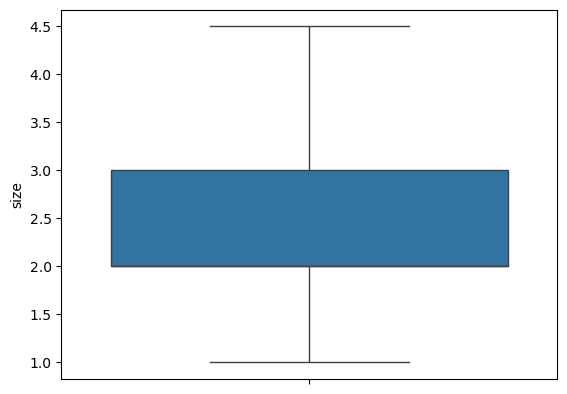

In [47]:
sns.boxplot(data=df['size'])

<Axes: ylabel='total_bill'>

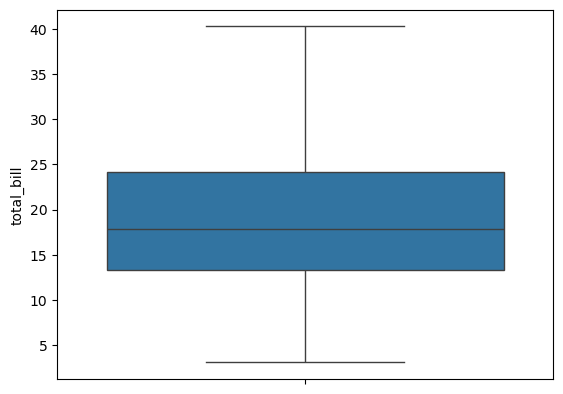

In [48]:
sns.boxplot(data=df['total_bill'])

<Axes: ylabel='tip'>

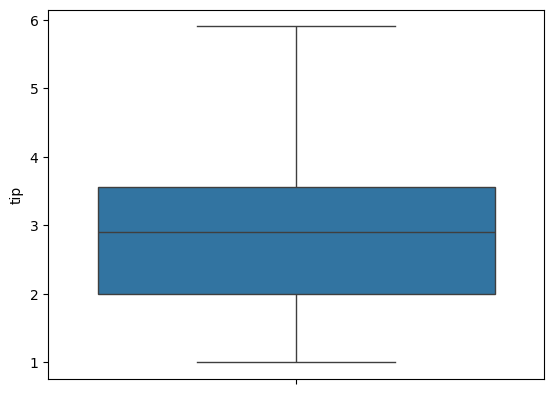

In [49]:
sns.boxplot(data=df['tip'])

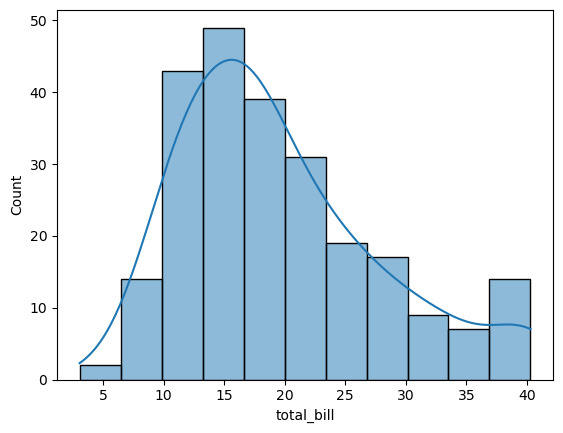

In [57]:
sns.histplot(data=df, x='total_bill', kde=True)
plt.show()
